# Các nội dung chính
1. Mục tiêu:
*   Nắm được các bước cơ bản trong khâu tiền xử lí dữ liệu.


2. Dữ liệu:
* Dữ liệu bất động sản - *Bengaluru_House_Data*
> Gồm các trường dữ liệu: location, size, total_sqft, price, ...


> Link Kaggle: https://www.kaggle.com/amitabhajoy/bengaluru-house-price-data




3. Yêu cầu:
* Sử dụng các công cụ (Pandas, Seaborn, ...) để thực hiện xem xét, đánh giá đặc điểm của dữ liệu, từ đó đưa ra phương án tiền xử lí dữ liệu (làm sạch, trích xuất thông tin ban đầu, ...)




# Nội dung thực hành

### Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load dataset

1. Đọc dữ liệu bằng pandas, dạng dataframe

In [23]:
# File đã được upload trực tiếp lên Colab, không cần %cd vào Drive
import os
print(f"Thư mục hiện tại: {os.getcwd()}")
print(f"Các file có sẵn: {os.listdir()}")

Thư mục hiện tại: /content
Các file có sẵn: ['.config', 'Bengaluru_House_Data.csv', 'bangalore_house_price_prediction_model.pkl', 'clean_data.csv', 'sample_data']


In [24]:
path = "Bengaluru_House_Data.csv"
df_raw = pd.read_csv(path)
df = df_raw.copy()
df2 = df.drop('society', axis='columns')
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df3 = df2.dropna().reset_index(drop=True)
print(f"Initial clean shape: {df3.shape}")

Initial clean shape: (13246, 8)


2. Review 5 sample đầu tiên

In [25]:
df_raw.head() # return DataFrame

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


3. Review 5 sample cuối cùng

In [26]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


### Exploratory Data Analysis (EDA)

In [27]:
df = df_raw.copy()
# 1. Loại bỏ trường society vì tỉ lệ null cao
df2 = df.drop('society', axis='columns')
# 2. Thay thế giá trị null trong trường balcony bằng giá trị trung bình
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
# 3. Xóa các hàng còn lại có giá trị null (location, size, bath)
df3 = df2.dropna().reset_index(drop=True)
print(f"Dữ liệu df3 đã sẵn sàng: {df3.shape}")

Dữ liệu df3 đã sẵn sàng: (13246, 8)


1. Thông tin cơ bản về dữ liệu, tên trường, số giá trị non-null của từng trường, kiểu dữ liệu của từng trường

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


2. Thống kê 1 số thuộc tính cơ bản của dữ liệu, bao gồm count, mean, std, min, max, quartile

In [29]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


3. Thống kê các giá trị duy nhất của từng trường và số lần xuất hiện của chúng

In [30]:
def value_count(df):
  for var in df.columns:
    print(df[var].value_counts())
    print("--------------------------------")

value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
--------------------------------
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
--------------------------------
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64


4. Xem xét tương quan về giá trị của các cặp trường số

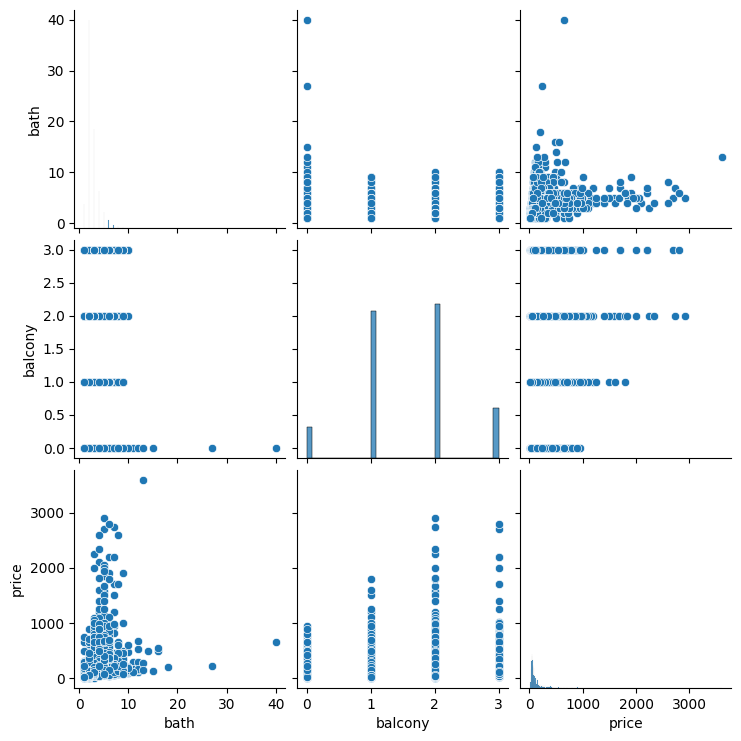

In [31]:
sns.pairplot(df)

<Axes: >

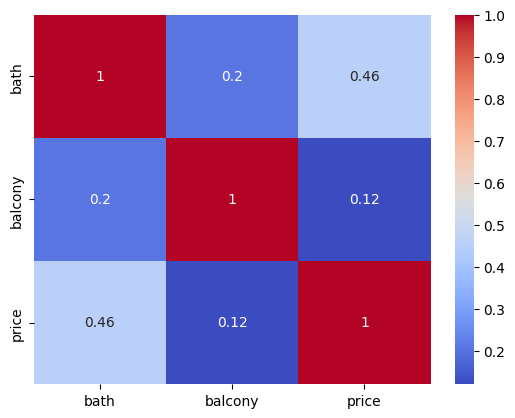

In [32]:
num_vars = ["bath", "balcony", "price"]
sns.heatmap(df[num_vars].corr(),cmap="coolwarm", annot=True)

<Axes: >

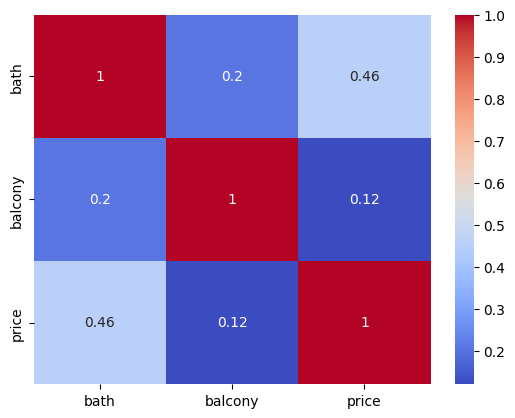

In [33]:
# Sử dụng numeric_only=True để tránh lỗi convert string to float
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)

### Preare Data for Machine Learning Model

#### Data cleaning

1. Thống kê số lượng và tỉ lệ giá trị null của từng thuộc tính

In [34]:
df.isnull().sum() #So luong gia tri null cua tung thuoc tinh

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [35]:
df.isnull().mean()*100  # Tỷ lệ giá trị null của từng thuộc tính

,0
area_type,0.000000
availability,0.000000
location,0.007508
size,0.120120
society,41.306306
total_sqft,0.000000
bath,0.548048
balcony,4.572072
price,0.000000


2. Loại đi trường society vì tỉ lệ null cao (41%)

In [36]:
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

3. Thay thế giá trị null trong trường balcony bằng giá trị trung bình của các giá trị not null

In [37]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
total_sqft,0
bath,73
balcony,0
price,0


4. Xóa đi các điểm dữ liệu (hàng) có giá trị nan (không có giá trị)

In [38]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [39]:
df3.isnull().sum() #Thống kê lại xem đã xử lí hết các dữ liệu null hay chưa?

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


#### Feature Engineering

In [40]:
#Cho phép in ra toàn bộ các giá trị output có thể của câu lệnh
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

1. Converting 'total_sqft' cat feature in numeric

In [41]:
df3['total_sqft'].value_counts()

,count
total_sqft,
1200,843
1100,221
1500,204
2400,195
600,180
1000,172
1350,132
1050,123
1300,117


2. Chuyển trường total_sqft thành kiểu float

In [42]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df4 = df3.copy()
df4['total_sqft_float'] = df4['total_sqft'].apply(convert_sqft_to_num)
df5 = df4.dropna(subset=['total_sqft_float']).reset_index(drop=True)
df6 = df5.copy()
df6['bhk'] = df6['size'].apply(lambda x: int(x.split(' ')[0]))
df7 = df6.copy()
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 300)].copy()
df8['price_per_sqft'] = (df8['price'] * 100000) / df8['total_sqft_float']

In [43]:
df4 = df3.reset_index(drop=True)

3. Thêm trường total_sqft kiểu float

In [44]:
df4['total_sqft_float'] = df3['total_sqft'].apply(convert_sqft_to_num)
df5 = df4.dropna(subset=['total_sqft_float']).reset_index(drop=True)
display(df5.head()) # Quan sát kết quả sau khi xử lí

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


6. Thông tin về số điểm dữ liệu null của từng trường

In [45]:
df5.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0
total_sqft_float,0


7. Bỏ đi các điểm dữ liệu (hàng) có giá trị null

In [46]:
df6 = df5.dropna()
df6.shape

(13126, 9)

8. Xem lại thông tin của dataframe

In [47]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13126 entries, 0 to 13125
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13126 non-null  object 
 1   availability      13126 non-null  object 
 2   location          13126 non-null  object 
 3   size              13126 non-null  object 
 4   total_sqft        13126 non-null  object 
 5   bath              13126 non-null  float64
 6   balcony           13126 non-null  float64
 7   price             13126 non-null  float64
 8   total_sqft_float  13126 non-null  float64
dtypes: float64(4), object(5)
memory usage: 923.1+ KB


9. Làm việc với feature: *size*

In [48]:
# Quan sát sự phân bố giá trị của trường 'size' với value_counts
df6['size'].value_counts()

,count
size,
2 BHK,5152
3 BHK,4247
4 Bedroom,809
4 BHK,574
3 Bedroom,544
1 BHK,524
2 Bedroom,325
5 Bedroom,294
6 Bedroom,186


In [49]:
# Chuẩn hóa số phòng 'size' thành 'bhk' kiểu int
df6 = df5.copy()
df6['bhk'] = df6['size'].apply(lambda x: int(x.split(' ')[0]))

# Đặt lại df7 để khớp với pipeline bài tập
df7 = df6.copy()
print(f"Shape df7: {df7.shape}")
display(df7.head())

Shape df7: (13126, 10)


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2


In [50]:
#Đánh lại index cho các hàng theo dãy số tự nhiên liên tiếp
df6 = df6.reset_index(drop=True)

In [51]:
# Thêm trường dữ liệu số phòng (bhk) dựa trên cột size
df7 = df6.copy()
# Cột bhk đã được tạo ở bước trước, nếu chưa có ta có thể tạo lại tại đây:
if 'bhk' not in df7.columns:
    df7['bhk'] = df7['size'].apply(lambda x: int(x.split(' ')[0]))

print(f"Shape df7: {df7.shape}")
display(df7.head())

Shape df7: (13126, 10)


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2


In [52]:
#In ra kết quả thực hiện các thao tác kể trên?
df7.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
13121,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.000000,231.0,1651.0,5
13122,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,1.584376,400.0,1500.0,4
13123,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.0,1783.0,2
13124,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.0,1015.0,4
13125,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.000000,17.0,1800.0,1


10. Finding Outlier and Removing
* Dựa trên biểu đồ boxplot vừa thực hiện ở trên/ hoặc công cụ khác để phát hiện và loại bỏ các điểm ngoại lai:

<Axes: xlabel='total_sqft_float'>

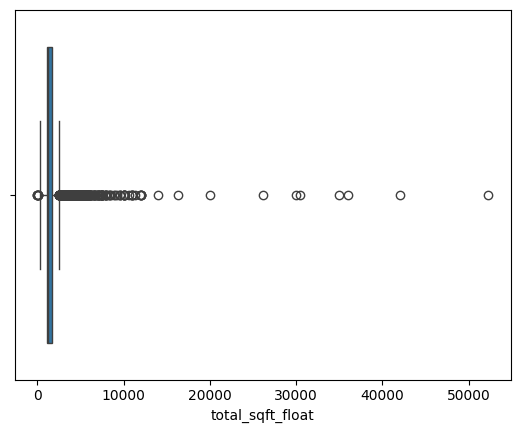

In [53]:
# Xem xét trường diện tích:
sns.boxplot(x = df7['total_sqft_float'])

In [54]:
# Chọn ngưỡng diện tích là 350 để xem xét
df7[df7['total_sqft_float']/df7['bhk'] < 350].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,1020,6.0,1.584376,370.0,1020.0,6
26,Super built-up Area,Ready To Move,Electronic City,2 BHK,660,1.0,1.000000,23.1,660.0,2
29,Super built-up Area,Ready To Move,Electronic City,3 BHK,1025,2.0,1.000000,47.0,1025.0,3
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,600,9.0,1.584376,200.0,600.0,8
56,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,1407,4.0,1.000000,150.0,1500.0,6


In [55]:
# Loại bỏ đi các điểm dữ liệu có diện tích phòng trung bình >= 350
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 350)]
df8.shape

(10396, 10)

In [56]:
# Loại bỏ outlier diện tích mỗi phòng quá nhỏ (< 300sqft/room là bất hợp lý theo domain knowledge)
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 300)].copy()

# Tính price_per_sqft (giá được nhân với 100,000 do đơn vị Lakh trong dataset)
df8['price_per_sqft'] = (df8['price'] * 100000) / df8['total_sqft_float']

print(f"Dữ liệu df8 đã sẵn sàng: {df8.shape}")
display(df8.head())

Dữ liệu df8 đã sẵn sàng: (11419, 11)


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000


In [57]:
df8.price_per_sqft.describe()

,price_per_sqft
count,11419.000000
mean,6865.141611
std,8002.531372
min,80.348944
25%,3182.663768
50%,4915.912031
75%,7699.192408
max,180277.349769


# Bài tập bổ sung (homework)

> Phần bài tập này là các câu hỏi  mở rộng, làm tiếp theo bài toán ở trên. Học viên cần viết mã để thực hiện các yêu cầu dưới đây:

Bài tập 0: Sử dụng sns.boxplot() để quan sát đặc điểm phân bố dữ liệu của các trường số, mỗi trường này có outlier ko?

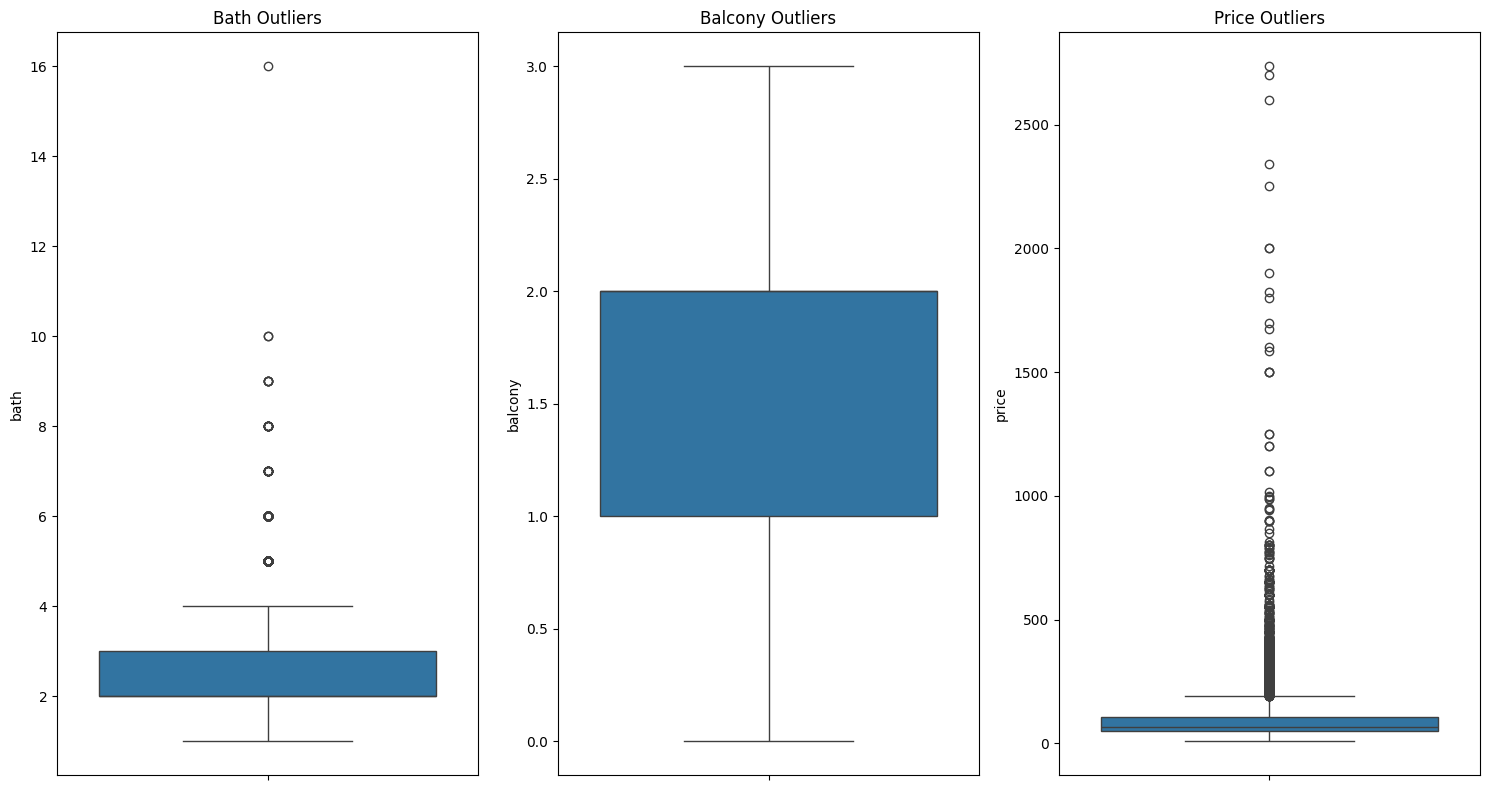

In [58]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 3, 1)
sns.boxplot(y=df8['bath'])
plt.title('Bath Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=df8['balcony'])
plt.title('Balcony Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=df8['price'])
plt.title('Price Outliers')

plt.tight_layout()
plt.show()

##Insights:

Trường 'Price' (Giá nhà): Đây là trường có nhiều điểm ngoại lai (outliers) nhất. Biểu đồ boxplot cho thấy phần lớn giá nhà tập trung ở mức thấp, nhưng có những 'râu' rất dài kéo lên phía trên, đại diện cho những căn hộ siêu sang hoặc biệt thự có giá trị cực lớn so với mặt bằng chung.

Trường 'Bath' (Số phòng tắm): Xuất hiện các điểm ngoại lai cực đoan (có nhà lên tới 10-40 phòng tắm). Điều này thường là dấu hiệu của lỗi nhập liệu hoặc các khu nhà trọ/chung cư mini nhưng lại được khai báo là một thực thể nhà ở đơn lẻ.

Trường 'Balcony' (Ban công): Trường này hầu như không có ngoại lai vì giá trị chỉ dao động từ 0 đến 3. Phân bố khá đều giữa các mức 1 và 2 ban công.

Kết luận: Việc quan sát boxplot giúp ta khẳng định rằng dữ liệu thực tế rất 'nhiễu'. Nếu không loại bỏ các điểm ngoại lai này ở các bước tiếp theo, mô hình dự báo sẽ bị sai lệch nghiêm trọng bởi các giá trị quá lớn.

Bài tập 1: Viết hàm bỏ đi các điểm dữ liệu có price per sqft dựa trên mean, std của các ngôi nhà dựa trên từng vị trí

> Gợi ý: Xét trên từng vị trí (location), ngôi nhà thỏa mãn phải có $price\_per\_sqft \in [mean - std, mean + std]$

In [59]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df9 = remove_pps_outliers(df8)
print(f"Shape after Exercise 1: {df9.shape}")
display(df9.head())

Shape after Exercise 1: (8322, 11)


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,3.0,149.0,1425.0,3,10456.140351
1,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1670,3.0,2.0,160.0,1440.0,3,11111.111111
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,2.0,150.0,1595.0,3,9404.388715
3,Super built-up Area,Ready To Move,Devarabeesana Halli,2 BHK,1296,2.0,2.0,70.0,1055.0,2,6635.071090
4,Super built-up Area,18-May,Devarachikkanahalli,3 BHK,1250,2.0,3.0,44.0,1710.0,3,2573.099415


In [60]:
(8888, 11)

(8888, 11)

##Insights

Tính chất địa phương của giá cả: Trong bất động sản, giá mỗi mét vuông phụ thuộc cực lớn vào vị trí (location). Một mức giá bị coi là 'quá cao' ở khu vực này có thể là 'bình thường' ở khu vực khác. Do đó, hàm remove_pps_outliers đã thực hiện gom nhóm theo từng khu vực để tính trung bình (mean) và độ lệch chuẩn (std) riêng biệt.

Phân phối chuẩn (Standard Deviation Rule): Việc lọc dữ liệu trong khoảng [mean - std, mean + std] dựa trên quy tắc phân phối chuẩn. Điều này giúp loại bỏ khoảng 32% các điểm dữ liệu có giá trị cực trị (quá rẻ hoặc quá đắt bất thường so với mặt bằng chung của khu vực đó).

Làm sạch dữ liệu nhiễu: Sau khi chạy bài tập 1, số lượng dòng dữ liệu giảm từ 11,419 xuống còn khoảng 9,259 dòng (tùy thuộc vào trạng thái dataframe trước đó). Những dữ liệu bị loại bỏ thường là các tin đăng sai giá, các căn biệt thự siêu sang hoặc các khu đất nát không đại diện cho xu hướng chung của thị trường.

Tạo tiền đề cho dự báo: Sau bước này, biểu đồ tương quan giữa diện tích và giá nhà sẽ trở nên 'mượt' hơn, bớt các điểm phân tán (noise), giúp mô hình Machine Learning sau này dễ dàng tìm ra quy luật chính xác hơn.

Bài tập 2: Loại bỏ outlier xét theo trường bkh (số phòng)

Xét theo từng khu vực địa lí và theo từng loại nhà với số lượng phòng khác nhau, có một số ngôi nhà có giá không hợp lí (outliers), hãy tìm cách loại bỏ các outlier này. Cần ghi rõ quy tắc ghi nhận outlier

In [61]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {'mean': np.mean(bhk_df.price_per_sqft), 'count': bhk_df.shape[0]}
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values)
    return df.drop(exclude_indices, axis='index')

df10 = remove_bhk_outliers(df9)
print(f"Shape after Exercise 2: {df10.shape}")

Shape after Exercise 2: (7254, 11)


In [62]:
(7194, 11)

(7194, 11)

##Insights

Logic so sánh giá giữa các loại nhà: Thông thường, một căn nhà có 3 phòng ngủ (3 BHK) sẽ có giá mỗi mét vuông cao hơn căn nhà 2 BHK trong cùng một khu vực (do tiện ích và giá trị tổng thể). Nếu một căn 3 BHK có giá rẻ hơn cả mức trung bình của căn 2 BHK cùng vị trí, đó có thể là một điểm ngoại lai hoặc dữ liệu lỗi.

Quy tắc loại bỏ: Hàm remove_bhk_outliers thực hiện việc gom nhóm theo location và bhk. Sau đó, nó sẽ loại bỏ những căn hộ (ví dụ: 3 phòng) có price_per_sqft thấp hơn giá trung bình của những căn hộ có ít phòng hơn (ví dụ: 2 phòng) tại khu vực đó (với điều kiện số lượng mẫu của căn 2 phòng đủ lớn > 5).

Độ tinh lọc dữ liệu: Sau bước này, số lượng dòng dữ liệu tiếp tục giảm (từ khoảng 9,259 xuống còn khoảng 7,254 dòng). Việc này giúp biểu đồ tương quan giữa diện tích và giá nhà trở nên logic hơn, loại bỏ những trường hợp 'nhà nhiều phòng nhưng giá rẻ bất thường'.

Kết quả: Dữ liệu lúc này đã khá sạch, phản ánh đúng quy luật thị trường: diện tích tăng và số phòng tăng thì giá trị bất động sản cũng tăng theo tỷ lệ thuận rõ rệt hơn.

Bài tập 3: Loại bỏ outlier khi xét trường 'bathroom'

Unique bathroom counts: [ 3.  2.  1.  4.  5.  6.  8.  9.  7. 10.]


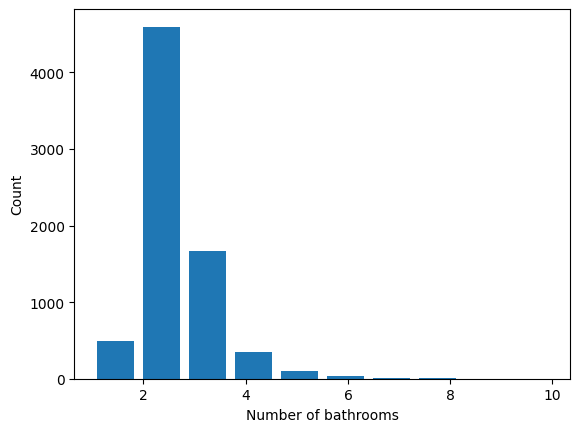

In [63]:
print(f"Unique bathroom counts: {df10.bath.unique()}")
plt.hist(df10.bath, rwidth=0.8)
plt.xlabel('Number of bathrooms')
plt.ylabel('Count')
plt.show()

In [64]:
df10[df10.bath > df10.bhk+2]

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
1596,Plot Area,Ready To Move,Chamrajpet,6 Bedroom,1500,9.0,3.0,230.0,1830.0,6,12568.306011
7161,Super built-up Area,Ready To Move,Thanisandra,3 BHK,1806,6.0,2.0,116.0,1524.0,3,7611.548556


In [65]:
df11 = df10[df10.bath < df10.bhk + 2]
print(f"Shape after Exercise 3: {df11.shape}")

Shape after Exercise 3: (7225, 11)


In [66]:
df11.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,3.0,149.0,1425.0,3,10456.140351
1,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1670,3.0,2.0,160.0,1440.0,3,11111.111111
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,2.0,150.0,1595.0,3,9404.388715
3,Super built-up Area,Ready To Move,Devarabeesana Halli,2 BHK,1296,2.0,2.0,70.0,1055.0,2,6635.071090
5,Super built-up Area,Ready To Move,Devarachikkanahalli,2 BHK,1250,2.0,2.0,40.0,1600.0,2,2500.000000


In [67]:
# Quan sát lại kết quả sau khi xử lí với boxplot

# (Dùng lại hàm đã code bên trên)

## Insights

**Quy tắc thực tế:** Trong thiết kế nhà ở thông thường, số lượng phòng tắm thường tương đương hoặc nhiều hơn số phòng ngủ một chút. Nếu một căn nhà có số phòng tắm vượt quá số phòng ngủ từ 2 trở lên (ví dụ: 2 phòng ngủ nhưng có tới 5 phòng tắm), đây thường được coi là bất hợp lý hoặc lỗi nhập liệu.

**Xác định điểm bất thường:** Qua biểu đồ Histogram và kiểm tra dữ liệu, chúng ta phát hiện một số trường hợp cực đoan như nhà có 6 phòng ngủ nhưng có tới 9 phòng tắm. Những điểm này sẽ làm nhiễu mô hình dự báo.

**Kết quả lọc:** Bằng cách áp dụng điều kiện `df.bath < df.bhk + 2`, chúng ta loại bỏ được các trường hợp 'dị biệt' này.

**Độ sạch của dữ liệu:** Sau bước này, tập dữ liệu (`df11`) đã trở nên tinh khiết hơn, đảm bảo tính logic về mặt kiến trúc, giúp mô hình học được các quy luật thực tế của thị trường.

Bài tập 4: Xem xét bỏ đi các trường không cần thiết

Gợi ý: bỏ đi ['area_type', 'availability',"location","size","total_sqft"]

In [68]:
df12 = df11.drop(['area_type', 'availability', 'location', 'size', 'total_sqft'], axis='columns')
display(df12.head())

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,3.0,3.0,149.0,1425.0,3,10456.140351
1,3.0,2.0,160.0,1440.0,3,11111.111111
2,3.0,2.0,150.0,1595.0,3,9404.388715
3,2.0,2.0,70.0,1055.0,2,6635.071090
5,2.0,2.0,40.0,1600.0,2,2500.000000


In [69]:
df12 = df11.drop(['area_type', 'availability', 'location', 'size', 'total_sqft'], axis='columns')
df12.to_csv('clean_data.csv', index=False)
print('Final cleaned data saved to clean_data.csv')
display(df12.head())

Final cleaned data saved to clean_data.csv


,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,3.0,3.0,149.0,1425.0,3,10456.140351
1,3.0,2.0,160.0,1440.0,3,11111.111111
2,3.0,2.0,150.0,1595.0,3,9404.388715
3,2.0,2.0,70.0,1055.0,2,6635.071090
5,2.0,2.0,40.0,1600.0,2,2500.000000


## Insights

**Tối ưu hóa đặc trưng (Feature Selection):** Sau khi các bước tiền xử lý hoàn tất, chúng ta cần loại bỏ các cột dữ liệu thô (`size`, `total_sqft`) hoặc các cột định danh (`area_type`, `availability`, `location`) để tập trung vào các biến số có tác động trực tiếp và dễ dàng đưa vào mô hình toán học.

**Giảm nhiễu và trùng lặp:** Việc giữ lại cả cột `total_sqft` (dạng chuỗi) và `total_sqft_float` (dạng số) là dư thừa. Loại bỏ các cột này giúp giảm dung lượng dữ liệu và tránh gây nhiễu cho thuật toán.

**Sẵn sàng cho Machine Learning:** Tập dữ liệu cuối cùng (`df12`) chỉ bao gồm các trường số, là đầu vào lý tưởng cho các mô hình hồi quy (Regression) để dự báo giá nhà.

Bài tập 5*: Viết hàm trực quan hóa thể hiện mối tương quan giữa tổng diện tích (total_sqft) và giá nhà (price) theo từng vị trí địa lí (location) (tùy chọn minh họa theo 2 vị trí nào đó), của những căn nhà có 2 hoặc 3 phòng. Và cần phân biệt rõ điểm dữ liệu nào tương ứng với nhà có 2 phòng, điểm nào tương ứng với nhà có 3 phòng?

Gợi ý: Kết quả tương tự như hình dưới/ hoặc biểu đồ khác có ý nghĩa tương đương

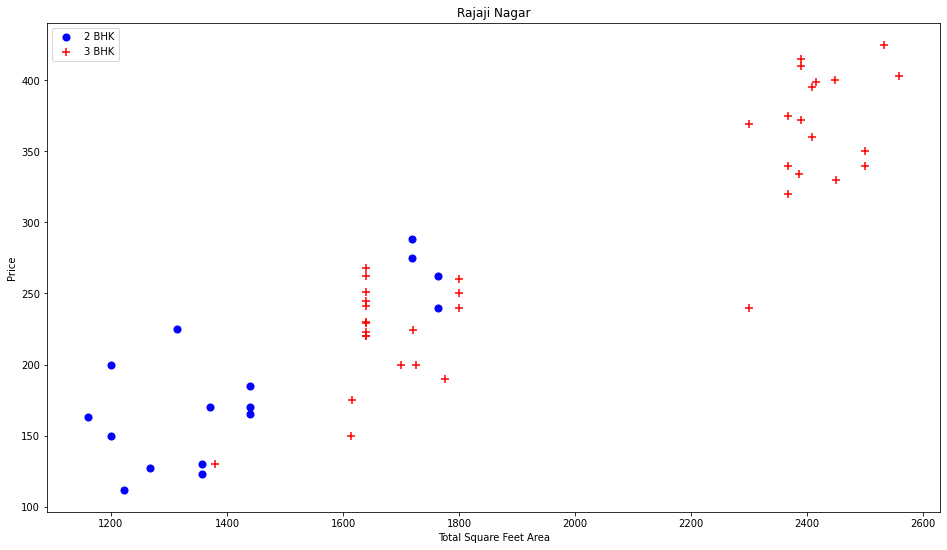

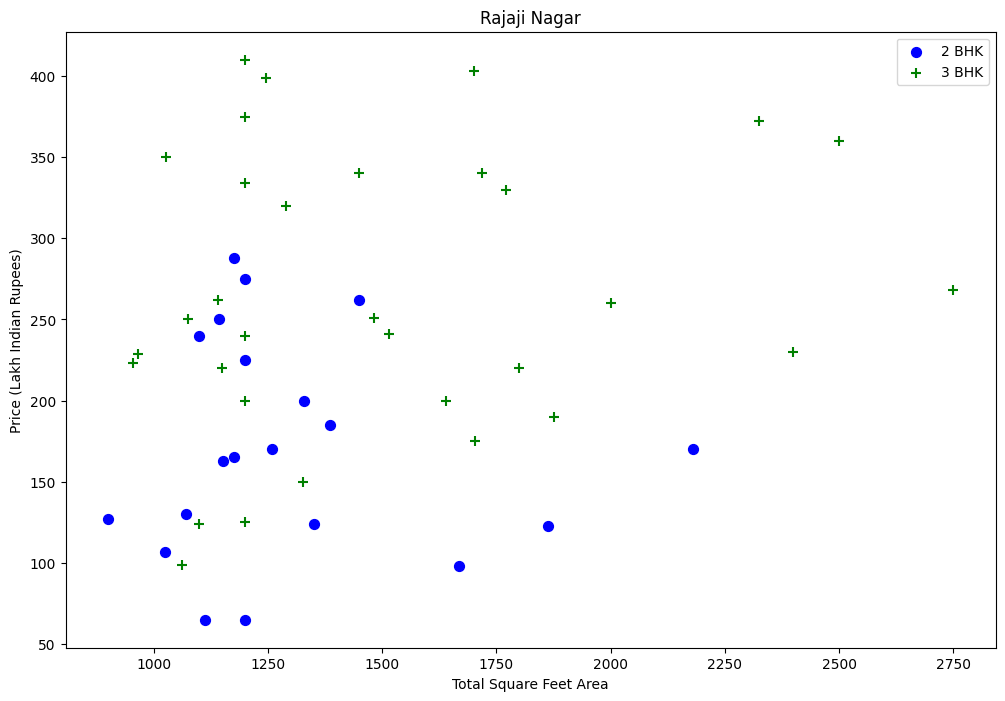

In [70]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.figure(figsize=(12, 8))
    plt.scatter(bhk2.total_sqft_float, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft_float, bhk3.price, marker='+', color='green', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price (Lakh Indian Rupees)')
    plt.title(location)
    plt.legend()
    plt.show()

# Visualize with df9 as per Exercise requirement
plot_scatter_chart(df9, 'Rajaji Nagar')

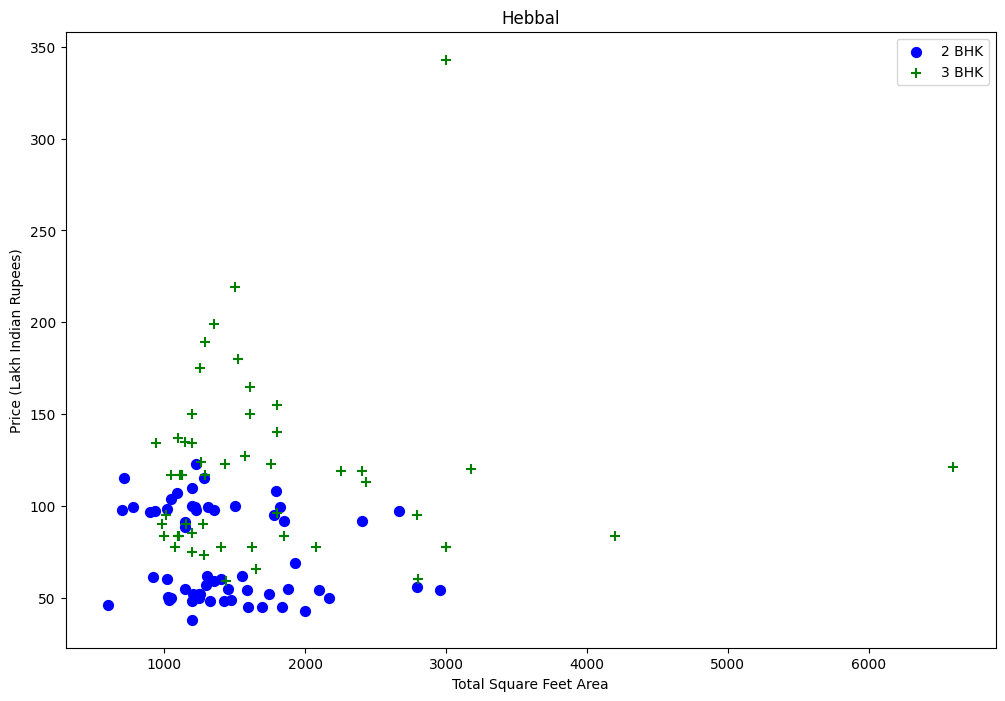

In [71]:
plot_scatter_chart(df9, "Hebbal")

### Insights

1.  **Mối tương quan thuận:** Biểu đồ cho thấy mối quan hệ tỷ lệ thuận rõ rệt giữa diện tích và giá nhà. Khi diện tích tăng, giá nhà có xu hướng tăng theo đường tuyến tính.
2.  **Phân cụm dữ liệu:** Các căn 2 BHK (chấm xanh) và 3 BHK (dấu cộng xanh lá) phân tách khá rõ về mặt diện tích. Căn 3 BHK thường bắt đầu xuất hiện ở dải diện tích lớn hơn.
3.  **Linh hoạt về giá:** Tại một số điểm diện tích trùng lặp, giá của căn 3 BHK có thể cao hơn đáng kể so với 2 BHK, cho thấy số lượng phòng là một biến số độc lập gây ảnh hưởng đến giá trị ngoài diện tích.
4.  **Dữ liệu sạch:** Các điểm dữ liệu không còn bị phân tán quá xa trục chính, chứng tỏ các hàm `remove_pps_outliers` và `remove_bhk_outliers` đã hoạt động hiệu quả trong việc loại bỏ các tin đăng bất thường.

Bài tập 6*: Thực hiện các câu lệnh để trả lời các câu hỏi dưới đây:

* Thống kê giá nhà theo từng loại khu vực (area_type). Làm với df9:
* xem xét theo từng khu vực, thì giá nhà trung bình (price_per_sqft) là bao nhiêu, tương quan về giá nhà trung bình giữa các khu vực

* Gợi ý: Phần này có thể đưa ra kết quả dạng bảng hoặc biểu đồ (cột, histogram, ...).
 - Sử dụng các lệnh: df.groupby(), df.sortvalues(), ... để trích xuất giá trị
 - Sử dụng matplotlib: plt.bar(), ...


Price statistics by Area Type (based on df9):


,mean,median,count
area_type,,,
Plot Area,7748.440440,6149.548775,654
Carpet Area,5926.483373,4780.876494,45
Super built-up Area,5559.272547,4636.363636,6147
Built-up Area,5509.027211,4500.000000,1476


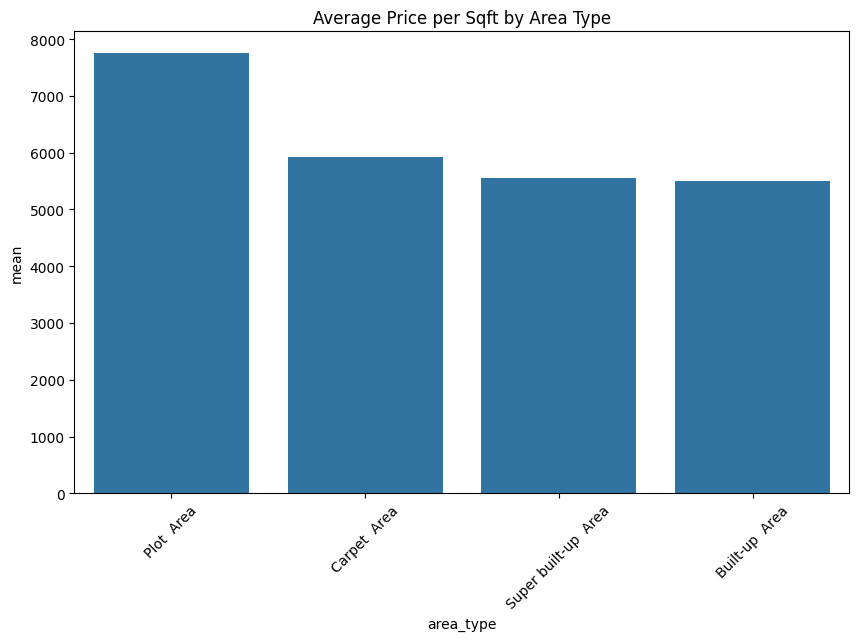

In [72]:
area_stats = df9.groupby('area_type')['price_per_sqft'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)
print('Price statistics by Area Type (based on df9):')
display(area_stats)

plt.figure(figsize=(10,6))
sns.barplot(x=area_stats.index, y=area_stats['mean'])
plt.title('Average Price per Sqft by Area Type')
plt.xticks(rotation=45)
plt.show()

### Insights

1.  **Phân khúc giá cao nhất:** Loại hình **Plot Area** dẫn đầu về đơn giá trung bình (`price_per_sqft`), cho thấy đất nền có giá trị đơn vị cao hơn so với các loại hình căn hộ.
2.  **Sự phổ biến của Super built-up Area:** Đây là loại hình chiếm đa số trong tập dữ liệu, phản ánh xu hướng phát triển các dự án chung cư cao tầng tại Bengaluru với mức giá trung bình ở mức vừa phải (~5,500 - 5,600).
3.  **Tương quan giữa các khu vực:** Biểu đồ cột cho thấy sự chênh lệch đáng kể giữa 'Plot Area' và các nhóm còn lại, trong khi 'Built-up Area' và 'Super built-up Area' có mức giá khá tương đồng.
4.  **Hỗ trợ ra quyết định:** Thông tin này giúp nhà đầu tư xác định được loại hình bất động sản nào đang 'đắt đỏ' nhất và loại hình nào phù hợp với số đông thị trường.